# Momentum Burst Strategy Backtest
This notebook implements the 3-8 day Momentum Burst Strategy using Linear Regression (LR) and RSI.

## The Strategy
1. **Macro Trend**: LR(34) slope > 0 (Green Background)
2. **Primer**: RSI(5) hooking up from oversold.
3. **Trigger**: LR(8) Acceleration crossing > 0
4. **Confirmation**: LR(8) ROC crossing > 0

## The Exit
- **Velocity Exit**: Exit when LR(8) Acceleration drops < 0.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Disable warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
def calc_rsi(series, period=5):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def calc_linreg(series, period):
    """Calculates Linear Regression value, slope, and intercept"""
    lr_values = pd.Series(index=series.index, dtype=float)
    lr_slopes = pd.Series(index=series.index, dtype=float)
    
    x = np.arange(period)
    
    for i in range(period - 1, len(series)):
        y = series.iloc[i - period + 1 : i + 1].values
        slope, intercept, _, _, _ = linregress(x, y)
        lr_slopes.iloc[i] = slope
        lr_values.iloc[i] = slope * (period - 1) + intercept
        
    return lr_values, lr_slopes

def calc_roc(series, period=5):
    # ROC is calculated over step 5 as seen in the charts
    return series.pct_change(periods=period) * 100


In [3]:
def generate_signals(df):
    # 1. Base indicators
    df['rsi_5'] = calc_rsi(df['close'], 5)
    
    # 2. Linear Regression (8 and 34)
    df['lr_8_fit'], df['lr_8_slope'] = calc_linreg(df['close'], 8)
    df['lr_34_fit'], df['lr_34_slope'] = calc_linreg(df['close'], 34)
    
    # 3. ROC of fit (Step 5 as seen in chart)
    df['lr_8_roc'] = calc_roc(df['lr_8_fit'], 5)
    df['lr_34_roc'] = calc_roc(df['lr_34_fit'], 5)
    
    # 4. Acceleration (Derivative of ROC)
    df['lr_8_accel'] = df['lr_8_roc'].diff()
    
    # Generate Entry Signals
    # Rule 1: Macro Trend Up
    macro_trend = df['lr_34_slope'] > 0
    
    # Rule 2: RSI(5) Hook up from below 50
    rsi_primer = (df['rsi_5'].rolling(3).min() < 50) & (df['rsi_5'] > df['rsi_5'].shift(1))
    
    # Rule 3: RSI 5-Day Breakout (Current RSI > Highest RSI of the previous 5 days)
    prev_5d_rsi_high = df['rsi_5'].shift(1).rolling(5).max()
    rsi_breakout = df['rsi_5'] > prev_5d_rsi_high
    
    # Rule 4: LR 8 Accel crossing above 0
    accel_cross_up = (df['lr_8_accel'] > 0) & (df['lr_8_accel'].shift(1) <= 0)
    
    short_trend = df['lr_8_roc'] > 0
    
    df['entry_signal'] = macro_trend & accel_cross_up & short_trend & rsi_primer & rsi_breakout
    
    # Generate Exit Signals
    # Velocity Exit: LR 8 Accel drops below 0
    accel_cross_down = (df['lr_8_accel'] < 0) & (df['lr_8_accel'].shift(1) >= 0)
    
    # Exhaustion Exit: RSI > 85 and hooking down
    rsi_exhaustion = (df['rsi_5'].shift(1) > 85) & (df['rsi_5'] < df['rsi_5'].shift(1))
    
    df['exit_signal'] = accel_cross_down | rsi_exhaustion
    
    return df


In [4]:
def backtest(df):
    in_trade = False
    entry_price = 0
    entry_date = None
    trades = []
    
    for i in range(len(df)):
        row = df.iloc[i]
        date = df.index[i]
        
        if not in_trade and row['entry_signal']:
            in_trade = True
            # Enter on next open (simulated here as current close for simplicity)
            entry_price = row['close']
            entry_date = date
            
        elif in_trade and row['exit_signal']:
            in_trade = False
            exit_price = row['close']
            
            pnl = (exit_price - entry_price) / entry_price * 100
            hold_days = (date - entry_date).days if hasattr(date, 'days') else i - df.index.get_loc(entry_date)
            
            trades.append({
                'Entry Date': entry_date,
                'Exit Date': date,
                'Entry Price': entry_price,
                'Exit Price': exit_price,
                'Hold Days': hold_days,
                'PnL %': pnl
            })
            
    return pd.DataFrame(trades)


In [5]:
def plot_trades(df, symbol, trades_df):
    # Only plot if there are actual trades
    if len(trades_df) == 0:
        return
        
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(16, 15), gridspec_kw={'height_ratios': [3, 1, 1, 1]})
    
    # Add conditions text above the plot
    cond_text = "ENTRY: LR(34) Slope > 0 AND RSI(5) hooks <50 AND RSI(5) Breaks 5-Day High AND Accel > 0\n"
    cond_text += "EXIT: LR(8) Accel drops < 0 OR RSI(5) drops from > 85 OR -2.5% Stop Loss"
    fig.suptitle(cond_text, fontsize=14, fontweight='bold', y=0.95)
    
    # Panel 1: Price and Trends
    ax1.plot(df.index, df['close'], label='Close', color='black', linewidth=1.5)
    ax1.plot(df.index, df['lr_8_fit'], label='LR(8) Fast', color='blue', alpha=0.7)
    ax1.plot(df.index, df['lr_34_fit'], label='LR(34) Slow', color='orange', alpha=0.7)
    
    # Highlight actual executed trades
    for idx, trade in trades_df.iterrows():
        entry_d = pd.to_datetime(trade['Entry Date'])
        exit_d = pd.to_datetime(trade['Exit Date'])
        ax1.scatter(entry_d, df.loc[entry_d, 'close'], marker='^', color='green', s=200, label='Entry' if idx==0 else "", zorder=5)
        ax1.scatter(exit_d, df.loc[exit_d, 'close'], marker='v', color='red', s=200, label='Exit' if idx==0 else "", zorder=5)
    
    ax1.set_title(f'{symbol} - Momentum Burst Trades')
    ax1.set_ylabel('Price')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Panel 2: Acceleration
    ax2.plot(df.index, df['lr_8_accel'], label='LR(8) Acceleration', color='blue')
    ax2.axhline(0, color='black', linewidth=1)
    ax2.set_ylabel('Acceleration')
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    # Panel 3: ROC
    ax3.plot(df.index, df['lr_8_roc'], label='LR(8) ROC', color='green')
    ax3.plot(df.index, df['lr_34_roc'], label='LR(34) ROC', color='red', alpha=0.7)
    ax3.axhline(0, color='black', linewidth=1)
    ax3.set_ylabel('ROC')
    ax3.legend(loc='upper left')
    ax3.grid(True, alpha=0.3)
    
    # Panel 4: RSI
    ax4.plot(df.index, df['rsi_5'], label='RSI(5)', color='purple')
    ax4.axhline(50, color='green', linestyle='--', alpha=0.5)
    ax4.axhline(85, color='red', linestyle='--', alpha=0.5)
    ax4.set_ylabel('RSI')
    ax4.legend(loc='upper left')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()



Trades for AAVAS: 2


,Entry Date,Exit Date,Entry Price,Exit Price,Hold Days,PnL %,Symbol
0,2019-06-07,2019-06-10,1413.800049,1393.550049,1,-1.43231,AAVAS
1,2019-06-11,2019-06-19,1414.699951,1470.000000,6,3.90896,AAVAS


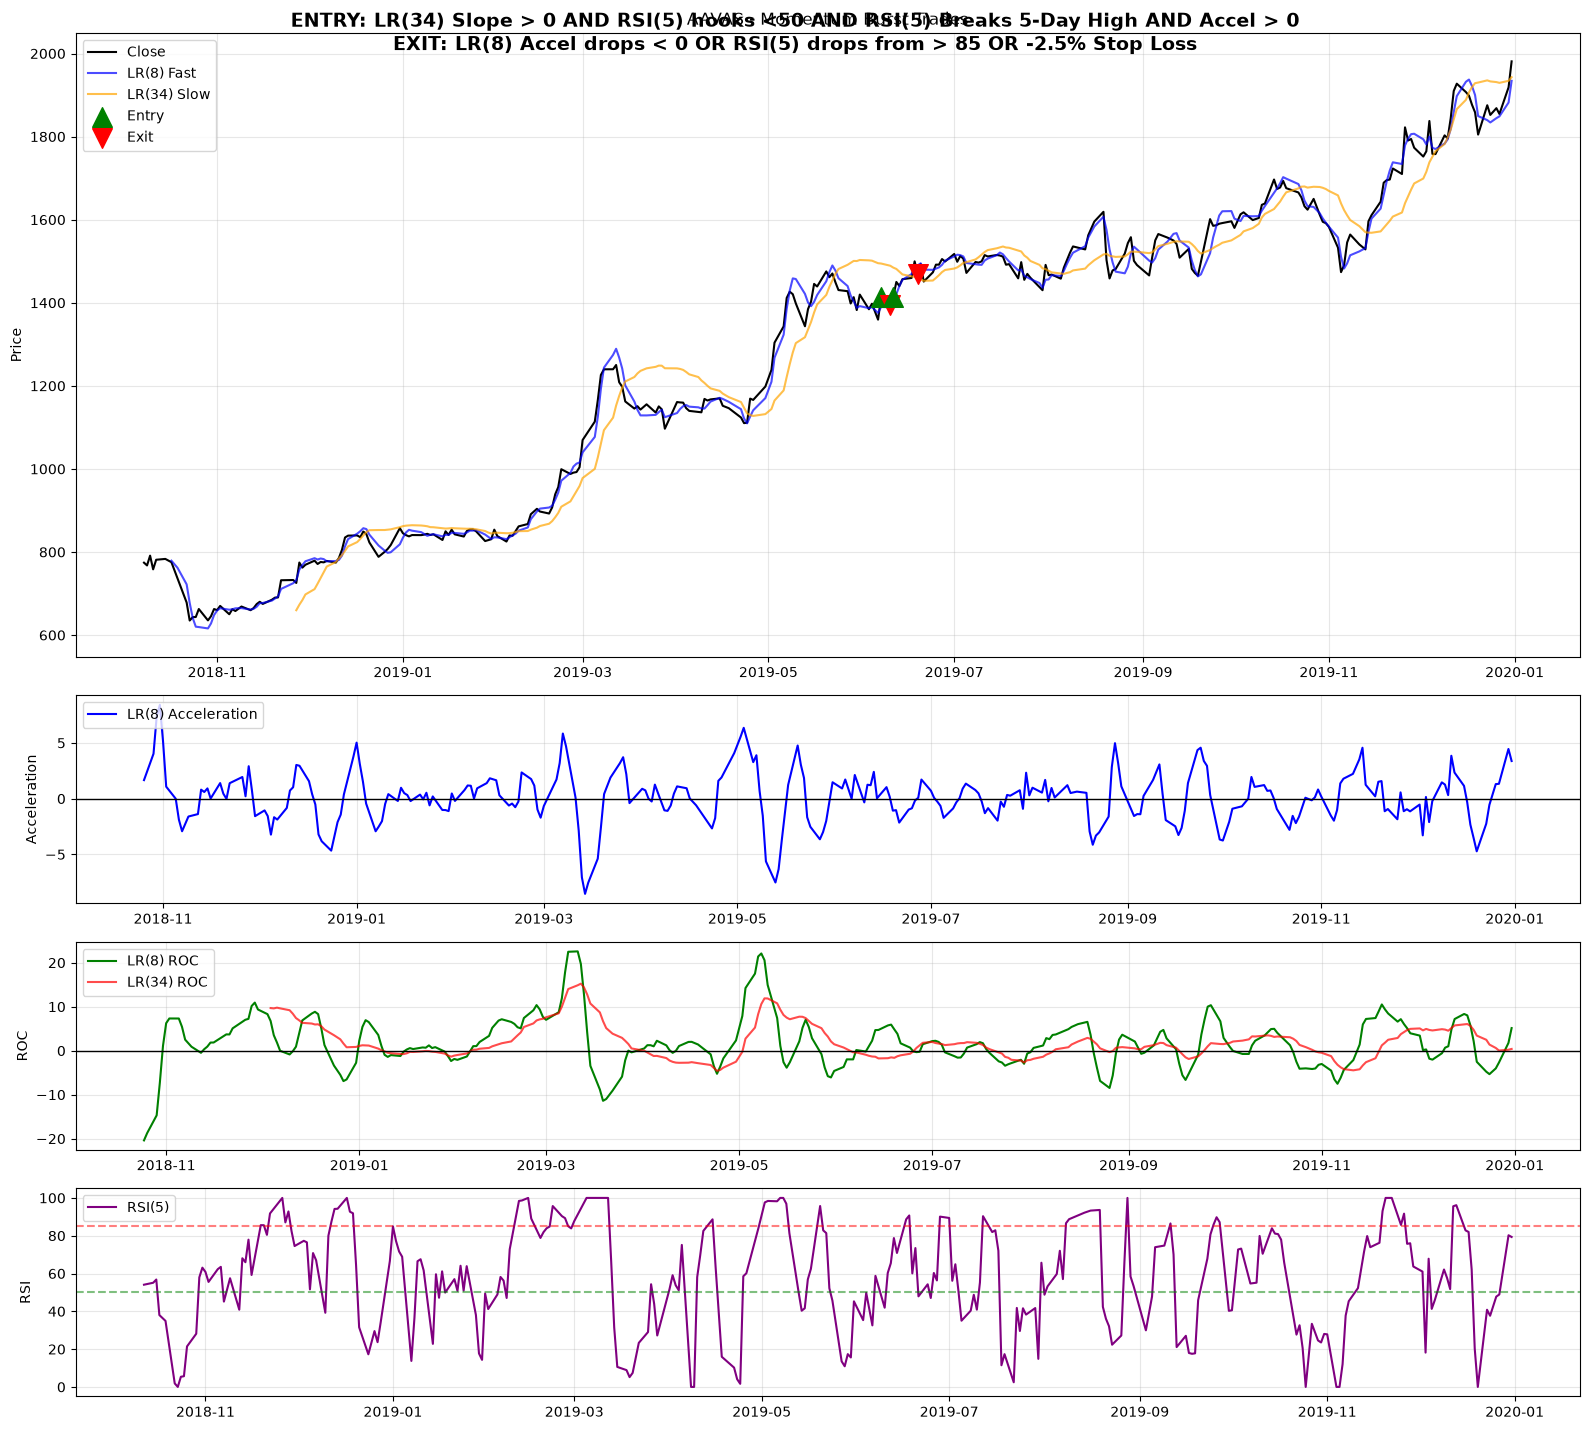


Trades for BATAINDIA: 3


,Entry Date,Exit Date,Entry Price,Exit Price,Hold Days,PnL %,Symbol
0,2018-04-20,2018-04-24,745.287598,728.744202,2,-2.219733,BATAINDIA
1,2018-04-30,2018-05-02,745.938171,722.981934,1,-3.077499,BATAINDIA
2,2018-07-20,2018-07-24,786.719360,838.364136,2,6.564574,BATAINDIA


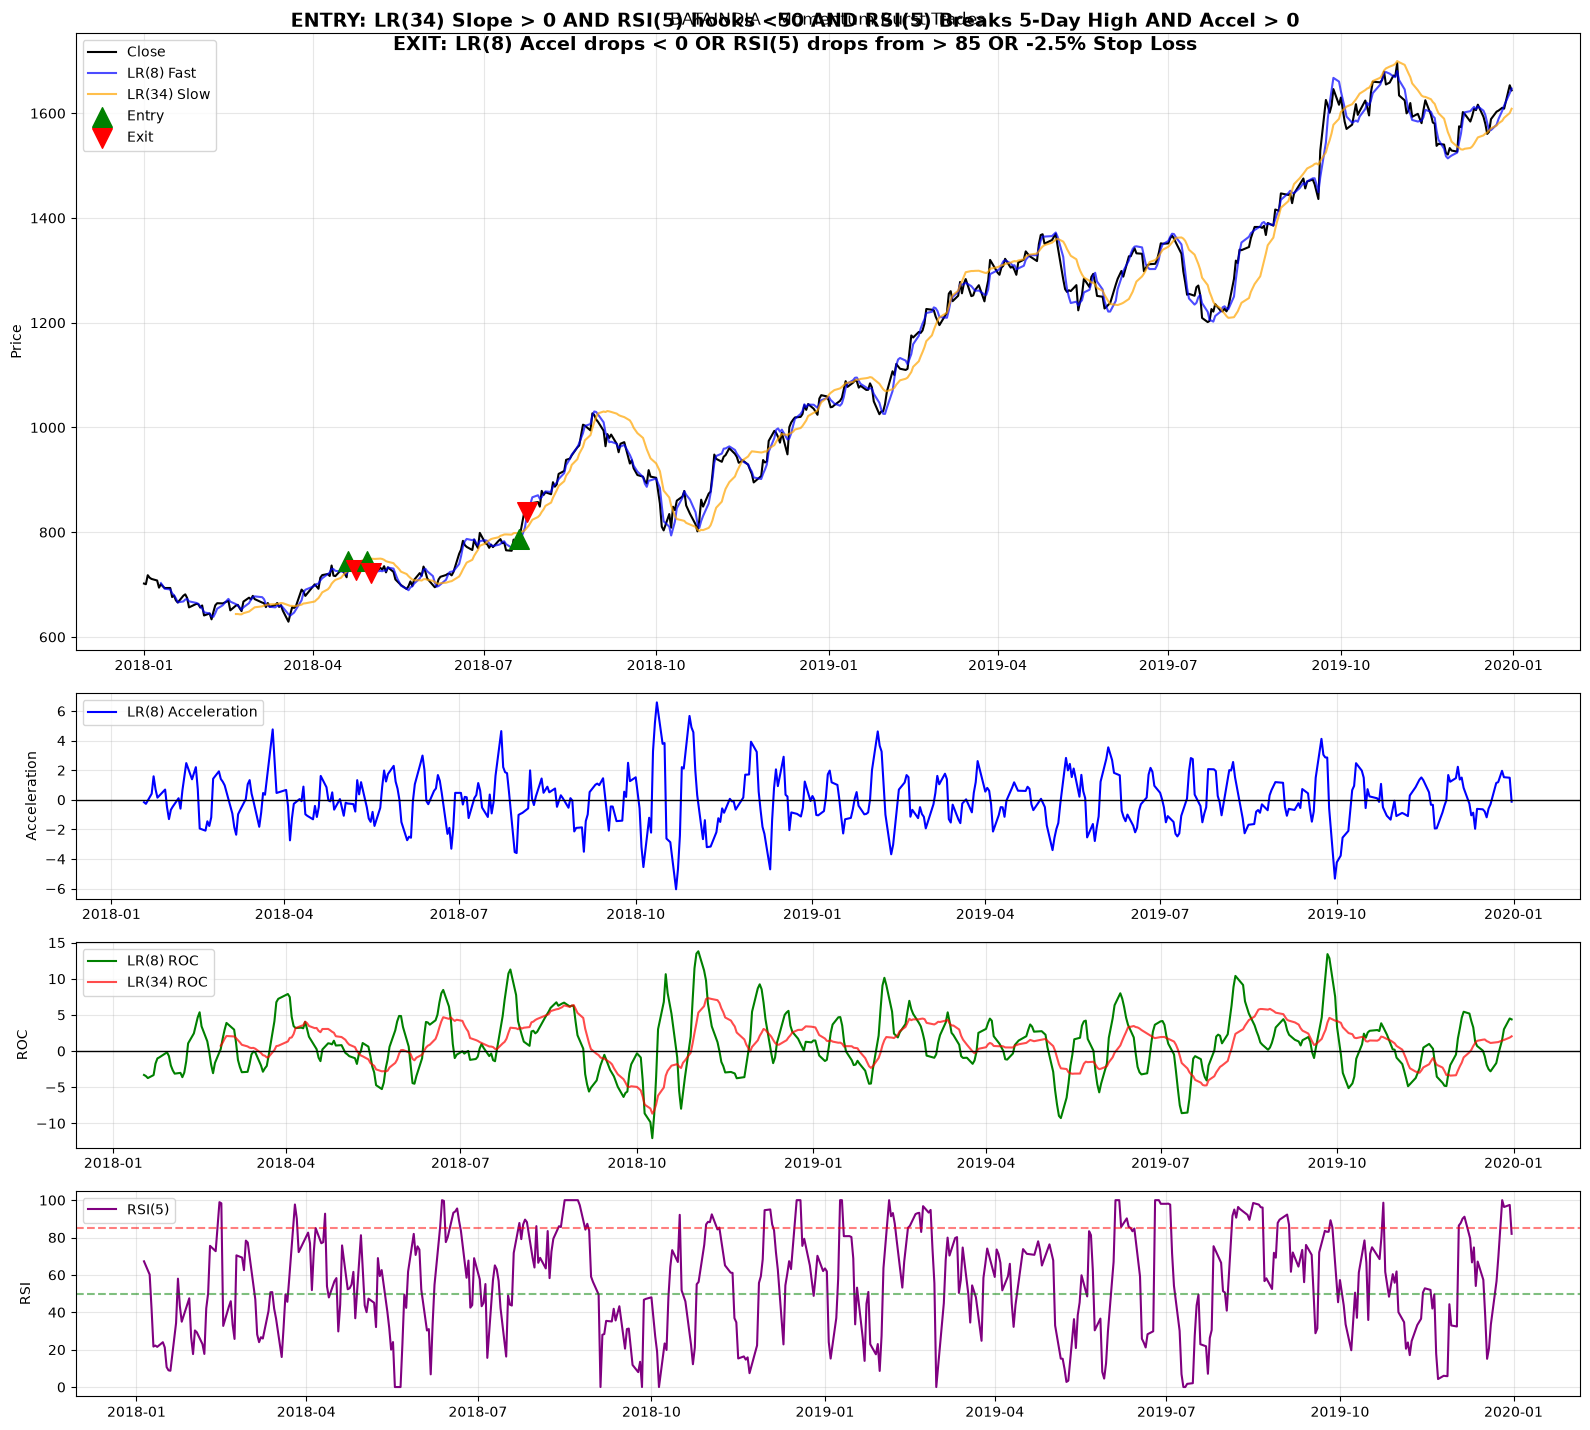


Trades for AJANTPHARM: 2


,Entry Date,Exit Date,Entry Price,Exit Price,Hold Days,PnL %,Symbol
0,2018-11-30,2018-12-03,722.077209,714.075073,1,-1.108211,AJANTPHARM
1,2019-05-02,2019-05-09,662.972595,657.720154,5,-0.792256,AJANTPHARM


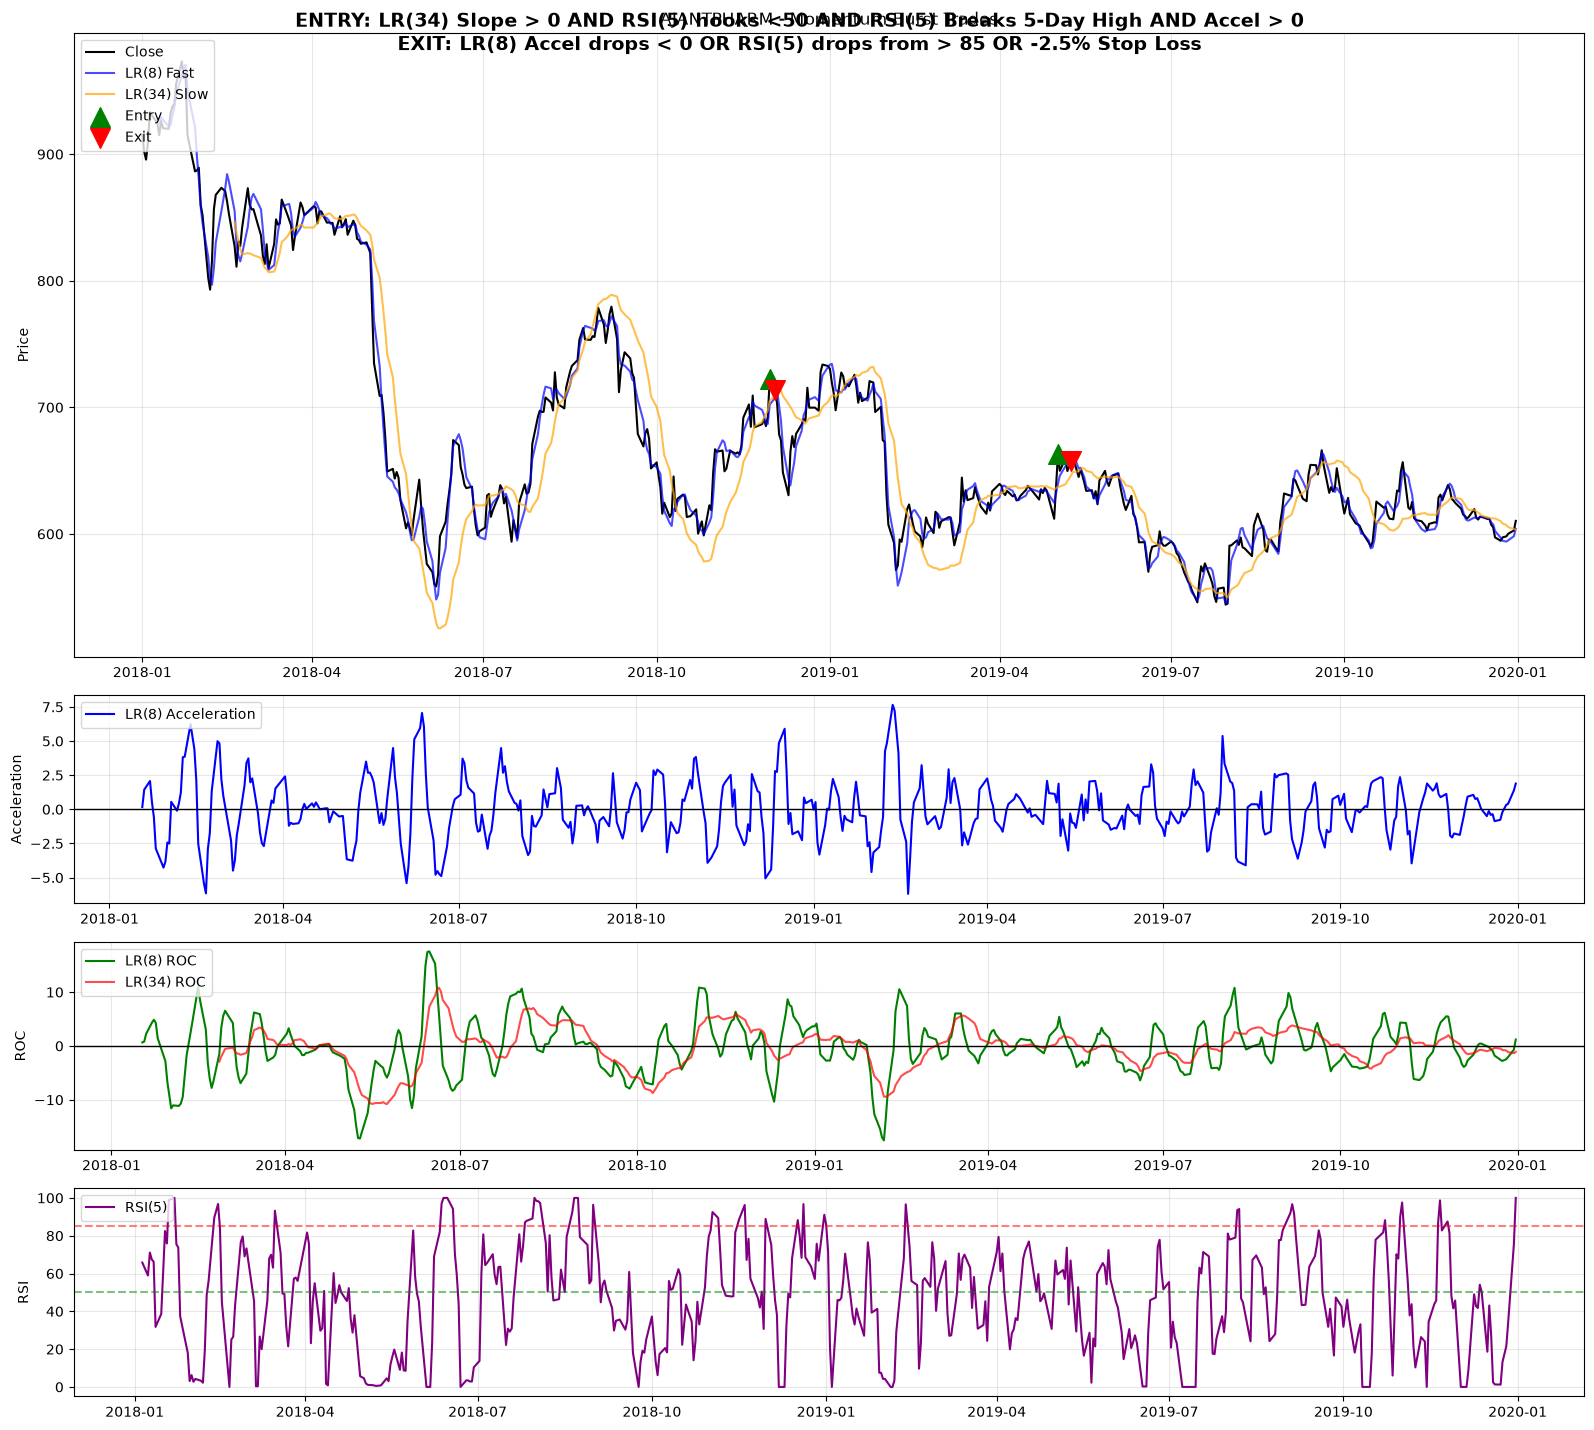


Trades for LALPATHLAB: 1


,Entry Date,Exit Date,Entry Price,Exit Price,Hold Days,PnL %,Symbol
0,2019-06-12,2019-06-17,508.394104,517.771118,3,1.844438,LALPATHLAB


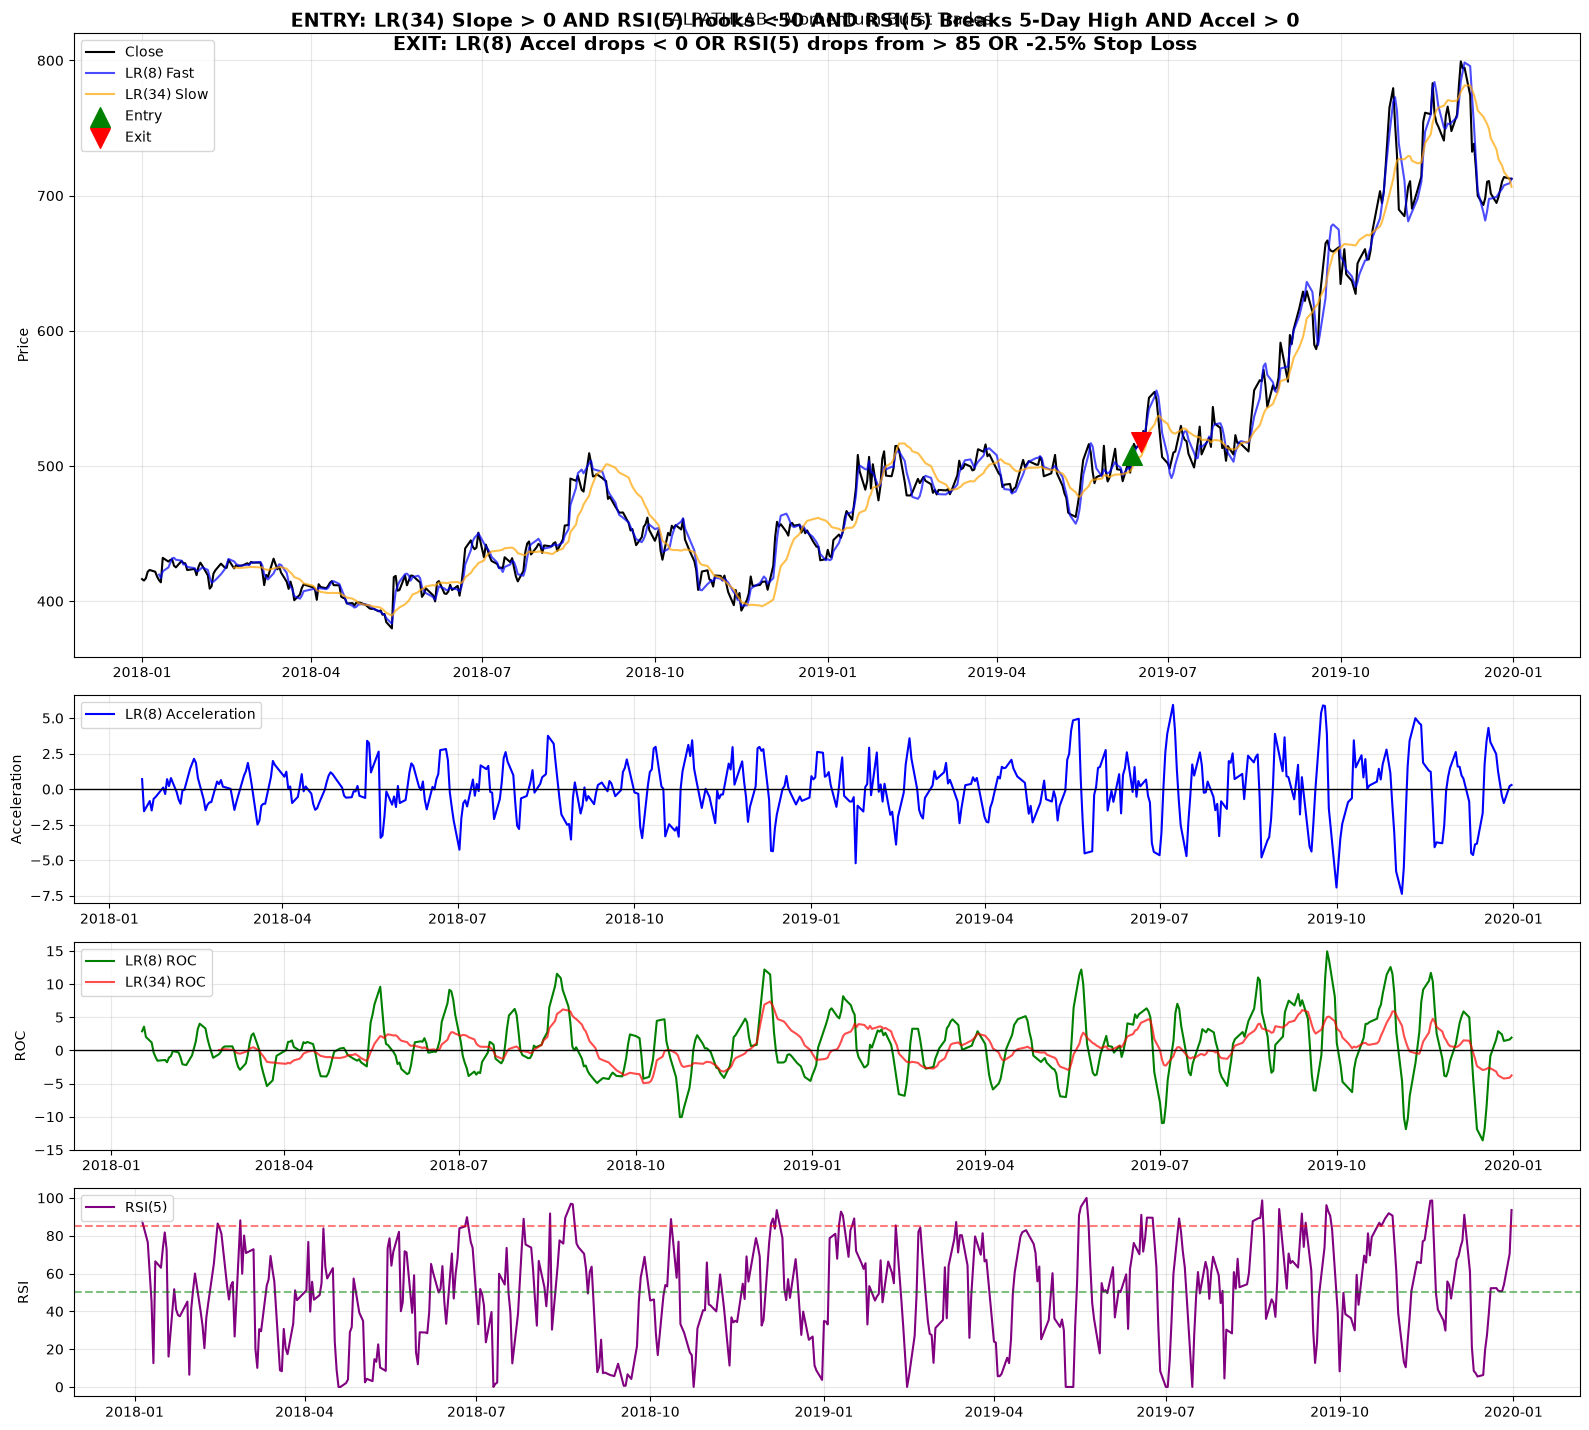


--- FINAL SUMMARY 2019 ---
Total Trades: 8
Win Rate: 37.50%


In [6]:
import os

stocks_to_test = ['AAVAS', 'CROMPTON', 'BATAINDIA', 'AJANTPHARM', 'LALPATHLAB']
data_dir = r"D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data"

all_results = []

for stock in stocks_to_test:
    file_path = os.path.join(data_dir, f"{stock}.csv")
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df.columns = [c.strip() for c in df.columns]
        
        if 'Adj Close' in df.columns: df['close'] = df['Adj Close']
        if 'Date' not in df.columns and 'date' in df.columns: df['Date'] = df['date']
        
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
        df['close'] = pd.to_numeric(df['close'], errors='coerce')
        df.dropna(subset=['close'], inplace=True)
        
        # Filter for 2018-2019 to give enough lookback padding for 2019 trades
        df = df[(df.index >= '2018-01-01') & (df.index <= '2019-12-31')]
    
        df = generate_signals(df)
        results = backtest(df)
        
        if len(results) > 0:
            results_df = pd.DataFrame(results)
            results_df['Symbol'] = stock
            all_results.append(results_df)
            print(f"\nTrades for {stock}: {len(results_df)}")
            display(results_df)
            plot_trades(df, stock, results_df)
    else:
        print(f"Data file not found at: {file_path}")

if all_results:
    final_df = pd.concat(all_results)
    print(f"\n--- FINAL SUMMARY 2019 ---")
    print(f"Total Trades: {len(final_df)}")
    print(f"Win Rate: {len(final_df[final_df['PnL %'] > 0]) / len(final_df) * 100:.2f}%")
